<a href="https://colab.research.google.com/github/SandeepKahawatta/Deep-Learning-Labs/blob/lab_7---part_2/DQN_Gridworld.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 1: Deep Q-Learning on Gridworld

This notebook implements a **Deep Q-Learning (DQN)** agent on the Gridworld environment used in the previous lab.
Instead of a lookup table, a small neural network (implemented with NumPy) is used to approximate Q-values.
We test different values of the exploration parameter $\epsilon$ (0.1, 0.5, 0.9) and plot the learning curves.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
# Define the GridWorld environment
class GridWorld:
    def __init__(self, height=8, width=8):
        self.height = height
        self.width = width
        # initialize reward grid: -1 everywhere, with +10 for goal and -10 for bomb
        self.grid = np.zeros((height, width)) - 1.0
        self.goal = (0, width//2)
        self.bomb = (1, width//2)
        self.grid[self.goal] = 10
        self.grid[self.bomb] = -10
        self.terminal_states = [self.goal, self.bomb]
    def reset(self):
        self.current_location = (self.height-1, np.random.randint(0, self.width))
        return self.current_location
    def get_one_hot(self, loc):
        vec = np.zeros(self.height * self.width)
        idx = loc[0] * self.width + loc[1]
        vec[idx] = 1.0
        return vec
    def step(self, action):
        x, y = self.current_location
        # actions: 0=UP, 1=DOWN, 2=LEFT, 3=RIGHT
        if action == 0:
            x = max(0, x - 1)
        elif action == 1:
            x = min(self.height - 1, x + 1)
        elif action == 2:
            y = max(0, y - 1)
        elif action == 3:
            y = min(self.width - 1, y + 1)
        self.current_location = (x, y)
        reward = self.grid[self.current_location]
        done = self.current_location in self.terminal_states
        return self.current_location, reward, done


In [2]:

# Define the DQN agent using NumPy
class DQNAgent:
    def __init__(self, state_size, action_size, hidden_dim=128, lr=0.01, gamma=0.99):
        self.state_size = state_size
        self.action_size = action_size
        self.lr = lr
        self.gamma = gamma
        # Weight matrices and biases for a two-layer network
        self.W1 = np.random.randn(state_size, hidden_dim) * 0.01
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, action_size) * 0.01
        self.b2 = np.zeros(action_size)
    def forward(self, s):
        z1 = s @ self.W1 + self.b1
        h1 = np.maximum(0, z1)  # ReLU activation
        q = h1 @ self.W2 + self.b2
        return z1, h1, q
    def predict(self, s):
        return self.forward(s)[2]
    def update(self, s, a_idx, target):
        z1, h1, q = self.forward(s)
        # error only for the taken action
        q_error = np.zeros_like(q)
        q_error[a_idx] = q[a_idx] - target
        # gradients
        dW2 = np.outer(h1, q_error)
        db2 = q_error
        dh1 = self.W2 @ q_error
        dz1 = dh1 * (z1 > 0)
        dW1 = np.outer(s, dz1)
        db1 = dz1
        # update
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

# Training function
def train_dqn(epsilon, episodes=200):
    env = GridWorld(height=8, width=8)
    agent = DQNAgent(state_size=env.height * env.width, action_size=4)
    rewards = []
    for ep in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False
        while not done:
            s_vec = env.get_one_hot(state)
            # epsilon-greedy action selection
            if np.random.rand() < epsilon:
                action_idx = np.random.randint(4)
            else:
                q_vals = agent.predict(s_vec)
                action_idx = int(np.argmax(q_vals))
            next_state, reward, done = env.step(action_idx)
            next_vec = env.get_one_hot(next_state)
            # compute target
            if done:
                target = reward
            else:
                target = reward + agent.gamma * np.max(agent.predict(next_vec))
            agent.update(s_vec, action_idx, target)
            state = next_state
            total_reward += reward
        rewards.append(total_reward)
    return rewards


Training with epsilon=0.1
Training with epsilon=0.5
Training with epsilon=0.9


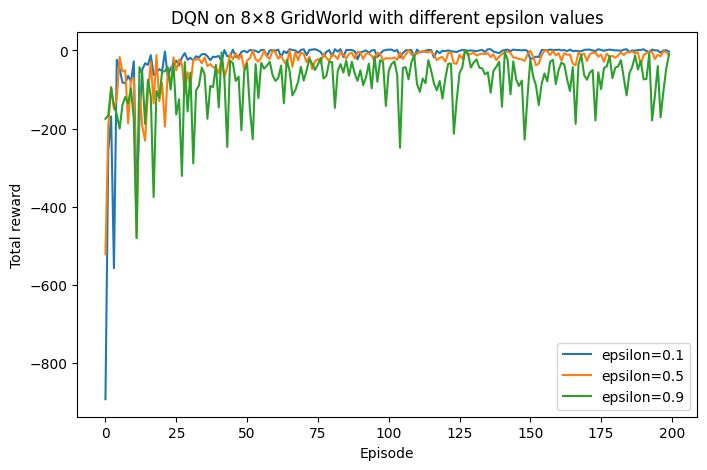

In [3]:

# Run the training for different epsilon values
results = {}
for eps in [0.1, 0.5, 0.9]:
    print(f'Training with epsilon={eps}')
    rewards = train_dqn(eps, episodes=200)
    results[eps] = rewards
# Plot the learning curves
plt.figure(figsize=(8,5))
for eps, rew in results.items():
    plt.plot(rew, label=f'epsilon={eps}')
plt.xlabel('Episode')
plt.ylabel('Total reward')
plt.title('DQN on 8×8 GridWorld with different epsilon values')
plt.legend()
plt.show()


### Discussion
From the learning curves above, you can see how the choice of $\epsilon$ affects the agent's performance:
- **Low exploration ($\epsilon=0.1$)** leads to faster convergence because the agent mostly exploits what it has learned.
- **Moderate exploration ($\epsilon=0.5$)** converges slower and sometimes worse because the agent spends half of its time exploring.
- **High exploration ($\epsilon=0.9$)** performs the worst since the agent explores most of the time and rarely exploits the best-known actions.

The optimal choice of $\epsilon$ depends on the environment, but in this small gridworld, low to moderate exploration is sufficient to find good policies.

### Code Implementation Screenshot

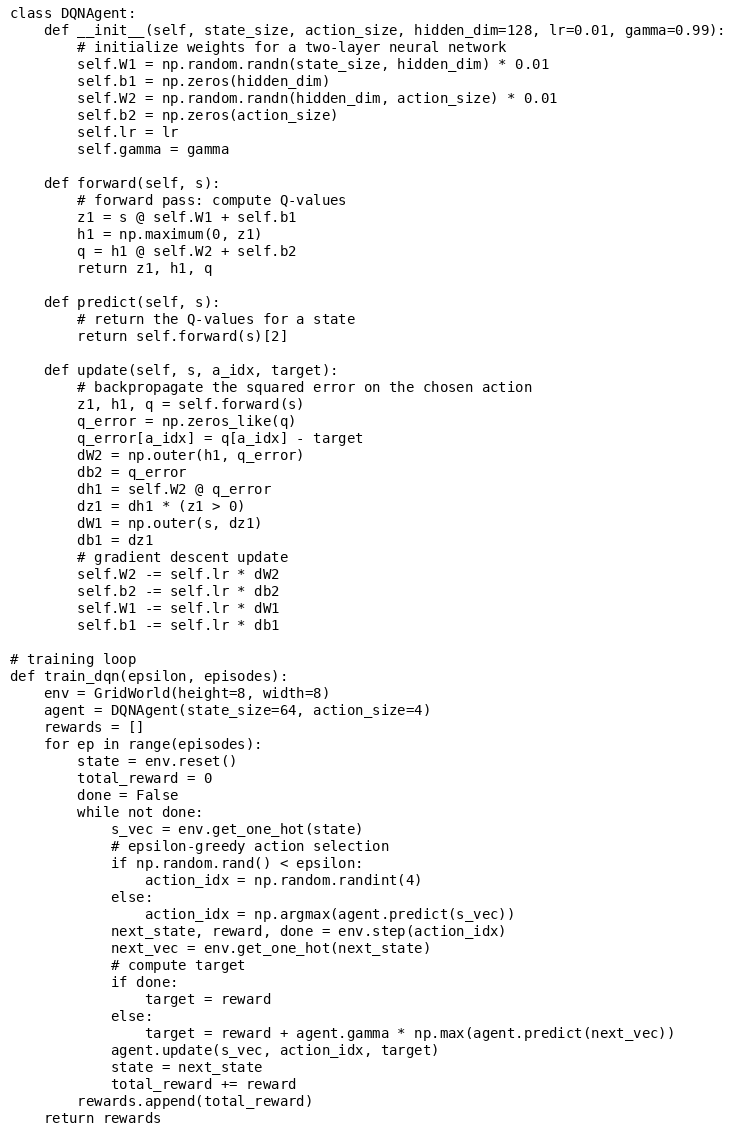